In [214]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [6]:
expr = pd.read_csv("desktop/TCGA_BRCA_Project/data/data_mrna_seq_v2_rsem.txt", sep="\t")

In [8]:
print(expr.shape)

(20531, 1084)


In [10]:
expr.head()

,Hugo_Symbol,Entrez_Gene_Id,TCGA-3C-AAAU-01,TCGA-3C-AALI-01,TCGA-3C-AALJ-01,TCGA-3C-AALK-01,TCGA-4H-AAAK-01,TCGA-5L-AAT0-01,TCGA-5T-A9QA-01,TCGA-A1-A0SB-01,...,TCGA-UL-AAZ6-01,TCGA-UU-A93S-01,TCGA-V7-A7HQ-01,TCGA-W8-A86G-01,TCGA-WT-AB41-01,TCGA-WT-AB44-01,TCGA-XX-A899-01,TCGA-XX-A89A-01,TCGA-Z7-A8R5-01,TCGA-Z7-A8R6-01
0,NaN,100130426,0.0000,0.0000,0.9066,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,NaN,100133144,16.3644,9.2659,11.6228,12.0894,6.8468,3.9889,1.4644,15.3396,...,0.3992,4.3126,0.0000,5.5624,0.0000,0.0000,14.3858,22.3240,2.2638,6.8865
2,UBE2Q2P2,100134869,12.9316,17.3790,9.2294,11.0799,14.4298,13.6090,8.9958,14.3935,...,14.3720,10.8828,3.0792,14.3711,6.3091,3.2580,21.4409,27.2744,7.2933,24.7795
3,HMGB1P1,10357,52.1503,69.7553,154.2970,143.8640,84.2128,114.2570,107.5630,116.3870,...,135.6240,136.1290,29.9974,128.3150,53.6278,42.2643,137.7760,64.1427,85.0461,167.5510
4,NaN,10431,408.0760,563.8930,1360.8300,865.5360,766.3830,807.7430,1420.5000,657.2810,...,1570.1400,2886.4000,1721.8800,697.6740,1245.2700,1877.4200,652.7560,722.7210,1140.2800,1003.5700


In [32]:
# We remove rows that do not have a gane name IE Hugo_Symbol is NaN

In [14]:
expr = expr.dropna(subset= ["Hugo_Symbol"])

In [18]:
print(expr.shape)

(20518, 1084)


In [34]:
# Now use gene names as row labels instead of 0,1,2,3...

In [22]:
expr= expr.set_index("Hugo_Symbol")

In [36]:
# Removing the gene ID since we only need the gene names

In [24]:
expr=expr.drop(columns= ["Entrez_Gene_Id"])

In [38]:
# Flipping the table so rows are patients and columns are genes, this is done since the ML needs the rows to be one sample and the olum to be the feature and right now its the opposite

In [26]:
expr=expr.T

In [28]:
print(expr.shape)

(1082, 20518)


In [30]:
expr.head()

Hugo_Symbol,UBE2Q2P2,HMGB1P1,RNU12-2P,SSX9P,EZHIP,EFCAB8,SRP14P1,TRIM75P,SPATA31B1P,REXO1L6P,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
TCGA-3C-AAAU-01,12.9316,52.1503,0.0000,0.0000,1.7233,0.3447,4.1359,0.6893,0.0,0.0,...,415.824,931.957,129.5920,1007.780,1658.500,258.4940,1208.370,3507.25,1894.930,1180.460
TCGA-3C-AALI-01,17.3790,69.7553,1.0875,0.5438,144.1000,4.8940,1.6313,0.5438,0.0,0.0,...,1161.330,965.198,59.8151,448.613,1343.120,198.4770,603.589,5504.62,1318.650,406.743
TCGA-3C-AALJ-01,9.2294,154.2970,0.0000,0.0000,0.0000,2.7199,2.7199,0.0000,0.0,0.0,...,305.422,2531.280,35.3581,533.998,768.812,331.8220,532.185,5458.75,942.883,509.519
TCGA-3C-AALK-01,11.0799,143.8640,0.4137,0.0000,0.0000,2.0687,4.5511,0.0000,0.0,0.0,...,394.506,668.597,55.0269,437.733,863.881,175.4240,607.365,5691.35,781.134,700.869
TCGA-4H-AAAK-01,14.4298,84.2128,0.4255,0.0000,0.4255,2.9787,2.9787,0.0000,0.0,0.0,...,405.711,674.468,48.9362,424.255,1049.790,14.0426,775.745,4041.70,831.915,881.702


In [44]:
# Now we have the gene data we still need the labels or subtypes so we load that in

In [48]:
clinical = pd.read_csv("desktop/TCGA_BRCA_Project/data/data_clinical_patient.txt", sep="\t", comment="#")

In [50]:
print(clinical.columns)

Index(['PATIENT_ID', 'SUBTYPE', 'CANCER_TYPE_ACRONYM', 'OTHER_PATIENT_ID',
       'AGE', 'SEX', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'AJCC_STAGING_EDITION',
       'DAYS_LAST_FOLLOWUP', 'DAYS_TO_BIRTH',
       'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'ETHNICITY',
       'FORM_COMPLETION_DATE', 'HISTORY_NEOADJUVANT_TRTYN', 'ICD_10',
       'ICD_O_3_HISTOLOGY', 'ICD_O_3_SITE', 'INFORMED_CONSENT_VERIFIED',
       'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'PATH_M_STAGE',
       'PATH_N_STAGE', 'PATH_T_STAGE', 'PERSON_NEOPLASM_CANCER_STATUS',
       'PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT', 'PRIOR_DX', 'RACE',
       'RADIATION_THERAPY', 'WEIGHT', 'IN_PANCANPATHWAYS_FREEZE', 'OS_STATUS',
       'OS_MONTHS', 'DSS_STATUS', 'DSS_MONTHS', 'DFS_STATUS', 'DFS_MONTHS',
       'PFS_STATUS', 'PFS_MONTHS', 'GENETIC_ANCESTRY_LABEL'],
      dtype='object')


In [52]:
clinical.head()

,PATIENT_ID,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,...,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,GENETIC_ANCESTRY_LABEL
0,TCGA-3C-AAAU,BRCA_LumA,BRCA,6E7D5EC6-A469-467C-B748-237353C23416,55,Female,STAGE X,6TH,4047.0,-20211.0,...,Yes,0:LIVING,133.050597,0:ALIVE OR DEAD TUMOR FREE,133.050597,1:Recurred/Progressed,59.440444,1:PROGRESSION,59.440444,EUR
1,TCGA-3C-AALI,BRCA_Her2,BRCA,55262FCB-1B01-4480-B322-36570430C917,50,Female,STAGE IIB,6TH,4005.0,-18538.0,...,Yes,0:LIVING,131.669790,0:ALIVE OR DEAD TUMOR FREE,131.669790,0:DiseaseFree,131.669790,0:CENSORED,131.669790,AFR
2,TCGA-3C-AALJ,BRCA_LumB,BRCA,427D0648-3F77-4FFC-B52C-89855426D647,62,Female,STAGE IIB,7TH,1474.0,-22848.0,...,Yes,0:LIVING,48.459743,0:ALIVE OR DEAD TUMOR FREE,48.459743,0:DiseaseFree,48.459743,0:CENSORED,48.459743,AFR_ADMIX
3,TCGA-3C-AALK,BRCA_LumA,BRCA,C31900A4-5DCD-4022-97AC-638E86E889E4,52,Female,STAGE IA,7TH,1448.0,-19074.0,...,Yes,0:LIVING,47.604958,0:ALIVE OR DEAD TUMOR FREE,47.604958,NaN,NaN,0:CENSORED,47.604958,AFR
4,TCGA-4H-AAAK,BRCA_LumA,BRCA,6623FC5E-00BE-4476-967A-CBD55F676EA6,50,Female,STAGE IIIA,7TH,348.0,-18371.0,...,Yes,0:LIVING,11.440971,0:ALIVE OR DEAD TUMOR FREE,11.440971,0:DiseaseFree,11.440971,0:CENSORED,11.440971,EUR


In [54]:
# Since the patient IDs in the clinical file and the expression file are different we are going to match them first, we do this by removing the -01 at the end of the patient IDs in the expression file

In [56]:
expr.index= expr.index.str[:12]

In [58]:
clinical = clinical.set_index("PATIENT_ID")

In [62]:
# Now that the ID's are the same in both files, we match them to each other.

In [66]:
common_ids= expr.index.intersection(clinical.index)

In [70]:
x= expr.loc[common_ids]
y= clinical.loc[common_ids]["SUBTYPE"]

In [72]:
print(x.shape)
print(y.shape)

(1082, 20518)
(1082,)


In [76]:
# This next line shows how many patients belong to each subtype

In [74]:
print(y.value_counts())

SUBTYPE
BRCA_LumA      499
BRCA_LumB      197
BRCA_Basal     171
BRCA_Her2       78
BRCA_Normal     36
Name: count, dtype: int64


In [96]:
print(y.isna().sum())

101


In [102]:
valid_ids= y.dropna().index

x= x.loc[valid_ids]
y= y.loc[valid_ids]

In [108]:
print(x.shape)
print(y.shape)
print(y.value_counts())
print(y.isna().sum())

(981, 20518)
(981,)
SUBTYPE
BRCA_LumA      499
BRCA_LumB      197
BRCA_Basal     171
BRCA_Her2       78
BRCA_Normal     36
Name: count, dtype: int64
0


In [386]:
#### Exploratory Analysis ####

In [138]:
# now that the data is set up and ready, what we need to do is split the data so we dont
#train and test on the same data. We want to see if the model works on new and unseen 
#data. We start off with Logistic Regression model since it is the best starting point
#since it is easy to train, is fast, and wont crash or get unstable immediately making 
#it a good baseline model.

In [84]:
model = LogisticRegression(max_iter=1000)

In [110]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state =42)

In [126]:
#this next line takes the split data thats labeled as train and learns the patterns from
#it so what it is doing right now is that it is taking the x values which are the
# patients and their genes and learning the gene expression for the respective gene and
# then it looks at the matching y values which tell it what subtype it is so it starts
#learning for each subtype which genes are more active and not active and updates its
#information attempting to find the pattern.

In [112]:
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [130]:
#This next line basically takes what it learned when we used .fit and now applying and
#testing it using the remaining split data to see if what it learned was right or not.
#Essentially what it is doing is now it is taking the x values that were not used when
#trying to learn the pattern and applying what it learned on it and trying to predict
#the subtype of the breast cancer given the gene expressions for each patient.

In [114]:
y_pred=model.predict(x_test)

In [136]:
#Now that the model did the prediction we test it using the known correct answers. we
#have y_pred which stored the values that the model predicted after being trained and
#we have the y_test which are the correct answers that we will use to compare to the 
#predicted answers to see how accurate the model actually was. In this case it was 80.2%
#accurate so out of 100 patients it was able to predict 80 accurately.

In [120]:
accuracy=accuracy_score(y_test, y_pred)
print(accuracy)

0.8020304568527918


In [124]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  BRCA_Basal       0.95      0.97      0.96        37
   BRCA_Her2       0.77      0.94      0.85        18
   BRCA_LumA       0.83      0.86      0.85       100
   BRCA_LumB       0.61      0.49      0.54        39
 BRCA_Normal       0.00      0.00      0.00         3

    accuracy                           0.80       197
   macro avg       0.63      0.65      0.64       197
weighted avg       0.79      0.80      0.80       197



In [140]:
#Based on the results above we can see that the model was able to identify Basal 
#subtype pretty well with an F1 score of 0.96, with subtype Her2 the F1 was 0.85 lower
#than the previous one but still good same with LumA which is the most common class 
#which should be learned well by the model. with LumB it performed with an F1 score of
#0.54 which is weak so it struggled here given it only had 39 cases, and with the Normal
#subtype it completely failed with a score of 0 meaning it predicted none of the 3 cases
#right. What this tells us is that the model handeled dominant casses well like LumA and
#Basal. The model performance was not uniform across subtypes, accuracy for this model 
#was driven by dominant classes, while minority classes were porrly predicted. the 80% 
#accuracy was missleading since it didn't show us the performance of each subtype. We 
#could assume that the model struggled with LumB since it is similar to LumA so the gene 
#patterns overlapped. and for normal subtype there were only 3 samples meaning the model
#never learned it. While overall accuracy reached about 80%, performance varied 
#significantly across subtypes, with strong classification of Basal and LumA tumors but 
#poor detection of LumB and Normal samples, likely due to class imbalace and overlapping
#gene expression profiles.

In [144]:
#Now we start to reduce features to see how the model performs with less features. we do
#this and reduce based on which genes varies and which ones stay the same throughout
#if the gene stays almost the same in every patient then it is useless and therefore we 
#remove it and keep only the ones that varies a lot, IE more likely to help distinguish 
#subtypes.

In [142]:
gene_variance= x.var()

In [146]:
#we will start with 1000 genes.

In [148]:
top_genes = gene_variance.sort_values(ascending=False).head(1000).index

In [150]:
x_reduced= x[top_genes]

In [152]:
# now we repeat everything and train again based on these 1000 genes using same patients

In [156]:
x_train, x_test, y_train, y_test = train_test_split(x_reduced, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print(accuracy_score(y_test, y_pred))

0.7868020304568528


In [158]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  BRCA_Basal       0.95      0.97      0.96        37
   BRCA_Her2       0.77      0.94      0.85        18
   BRCA_LumA       0.82      0.86      0.84       100
   BRCA_LumB       0.57      0.41      0.48        39
 BRCA_Normal       0.00      0.00      0.00         3

    accuracy                           0.79       197
   macro avg       0.62      0.64      0.63       197
weighted avg       0.78      0.79      0.78       197



In [160]:
#The results when using 1000 features where barely any different, all the subtypes
#results performed the same with Basal, LumA showing good and stable reports and LumB 
#slightly worse, and normal still 0. Reducing feature dimensionality from about 20,000
#to 1,000 genes resulted in minimal loss of overall accuracy, suggesting that most genes
#do not contribute significantly to classification performance. Also despite lower size,
#Her2 tumors were classified more accurately than LumB, suggesting that subtype 
#separability, rather than class frequency, drives model performance.

In [162]:
#now we will test using 100 genes.

In [164]:
top_genes = gene_variance.sort_values(ascending=False).head(100).index

In [166]:
x_reduced= x[top_genes]

In [168]:
x_train, x_test, y_train, y_test = train_test_split(x_reduced, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print(accuracy_score(y_test, y_pred))

0.7969543147208121


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [172]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print(accuracy_score(y_test, y_pred))

0.7868020304568528


In [174]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  BRCA_Basal       0.92      0.92      0.92        37
   BRCA_Her2       0.76      0.89      0.82        18
   BRCA_LumA       0.83      0.87      0.85       100
   BRCA_LumB       0.60      0.46      0.52        39
 BRCA_Normal       0.00      0.00      0.00         3

    accuracy                           0.79       197
   macro avg       0.62      0.63      0.62       197
weighted avg       0.78      0.79      0.78       197



In [176]:
#Classification performance remains stable even with drastic feature reduction, 
#suggesting that a small subset of genes captures modt of the predictive signal.

In [178]:
#now we push further by doing 50 instead

In [186]:
top_genes = gene_variance.sort_values(ascending=False).head(50).index

x_reduced= x[top_genes]

x_train, x_test, y_train, y_test = train_test_split(x_reduced, y, test_size=0.2, random_state=42)

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print(accuracy_score(y_test, y_pred))

0.7614213197969543


In [188]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  BRCA_Basal       0.94      0.89      0.92        37
   BRCA_Her2       0.71      0.83      0.77        18
   BRCA_LumA       0.81      0.85      0.83       100
   BRCA_LumB       0.52      0.44      0.47        39
 BRCA_Normal       0.00      0.00      0.00         3

    accuracy                           0.76       197
   macro avg       0.60      0.60      0.60       197
weighted avg       0.76      0.76      0.76       197



In [190]:
#now that we reduced the size to only 50 genes, we see the biggest drop in performance, 
#the percentage dropped 2.5% meaning that now we are starting to remove important genes.

In [192]:
top_genes = gene_variance.sort_values(ascending=False).head(75).index

x_reduced= x[top_genes]

x_train, x_test, y_train, y_test = train_test_split(x_reduced, y, test_size=0.2, random_state=42)

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print(accuracy_score(y_test, y_pred))

0.7918781725888325


In [194]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  BRCA_Basal       0.94      0.92      0.93        37
   BRCA_Her2       0.71      0.83      0.77        18
   BRCA_LumA       0.83      0.86      0.84       100
   BRCA_LumB       0.62      0.54      0.58        39
 BRCA_Normal       0.00      0.00      0.00         3

    accuracy                           0.79       197
   macro avg       0.62      0.63      0.62       197
weighted avg       0.78      0.79      0.79       197



In [196]:
# model performance remained stable when reducing features from 20,000 to 75-100 genes,
#suggesting that subtypes classification relies on a relatively small subset of 
#information genes. However, further reduction to 50 genes resulted in decresed accuracy,
#indicating loss off critical predictive information.

In [198]:
# Now we will test using Random Forest model

In [262]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [264]:
#Pick the top 100 genes with the most variation across patients.
#Create a smaller version of x using only those genes.

In [266]:
n_genes = 20518 

In [268]:
top_genes = gene_variance.sort_values(ascending = False).head(n_genes).index
x_reduced = x[top_genes]

In [270]:
#Now we use 80% of patients to train and 20% to test.

In [272]:
x_train, x_test, y_train, y_test = train_test_split(
    x_reduced, y, test_size=0.2, random_state=42, stratify=y
)

In [274]:
#now we create the random forest model, n_estimators means the forest uses 500 decision
#trees, class_weight balanced since some subtypes have fewer patients, and random_state
#is 42 to make results reprofucible.

In [276]:
rf_model = RandomForestClassifier(
    n_estimators= 500,
    random_state= 42,
    class_weight = "balanced"
)

In [278]:
rf_model.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=42)

In [279]:
y_pred_rf = rf_model.predict(x_test)

In [280]:
#Random Forest failed to predict certain minority classes under reduced feature sets, 
#indicating sensitivity to class imbalance and potential loss of discriminative signal
#for rare subtypes.

In [281]:
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))

0.8426395939086294
              precision    recall  f1-score   support

  BRCA_Basal       0.94      1.00      0.97        34
   BRCA_Her2       1.00      0.50      0.67        16
   BRCA_LumA       0.80      0.98      0.88       100
   BRCA_LumB       0.84      0.65      0.73        40
 BRCA_Normal       0.00      0.00      0.00         7

    accuracy                           0.84       197
   macro avg       0.72      0.63      0.65       197
weighted avg       0.82      0.84      0.82       197



In [282]:
#Random Forest models failed to predict the Normal subtype, likely due to severe
#class imbalance and insufficient representation in the dataset. This highlights a 
#limitation of ensemble methods in detecting rare classes, particularly under reduced 
#feature sets.

#Despite achieving high overall accuracy, the model demonsrtrated an inability to 
#classify rare subtypes, underscoring the importance of evaluating class-specific 
#performance beyond aggregate metrics.

In [288]:
n_genes = 1000

In [290]:
top_genes = gene_variance.sort_values(ascending = False).head(n_genes).index
x_reduced = x[top_genes]

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators= 500,
    random_state= 42,
    class_weight = "balanced"
)

rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))

0.8324873096446701
              precision    recall  f1-score   support

  BRCA_Basal       0.97      1.00      0.99        34
   BRCA_Her2       1.00      0.81      0.90        16
   BRCA_LumA       0.77      0.97      0.86       100
   BRCA_LumB       0.86      0.47      0.61        40
 BRCA_Normal       1.00      0.14      0.25         7

    accuracy                           0.83       197
   macro avg       0.92      0.68      0.72       197
weighted avg       0.85      0.83      0.81       197



In [291]:
n_genes = 100
top_genes = gene_variance.sort_values(ascending = False).head(n_genes).index
x_reduced = x[top_genes]

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators= 500,
    random_state= 42,
    class_weight = "balanced"
)

rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))

0.8324873096446701
              precision    recall  f1-score   support

  BRCA_Basal       0.97      1.00      0.99        34
   BRCA_Her2       1.00      0.69      0.81        16
   BRCA_LumA       0.77      0.98      0.86       100
   BRCA_LumB       0.91      0.53      0.67        40
 BRCA_Normal       0.00      0.00      0.00         7

    accuracy                           0.83       197
   macro avg       0.73      0.64      0.67       197
weighted avg       0.82      0.83      0.81       197



In [292]:
n_genes = 75
top_genes = gene_variance.sort_values(ascending = False).head(n_genes).index
x_reduced = x[top_genes]

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators= 500,
    random_state= 42,
    class_weight = "balanced"
)

rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))

0.8223350253807107
              precision    recall  f1-score   support

  BRCA_Basal       0.92      1.00      0.96        34
   BRCA_Her2       1.00      0.75      0.86        16
   BRCA_LumA       0.76      0.99      0.86       100
   BRCA_LumB       0.94      0.42      0.59        40
 BRCA_Normal       0.00      0.00      0.00         7

    accuracy                           0.82       197
   macro avg       0.72      0.63      0.65       197
weighted avg       0.82      0.82      0.79       197



In [293]:
n_genes = 50
top_genes = gene_variance.sort_values(ascending = False).head(n_genes).index
x_reduced = x[top_genes]

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators= 500,
    random_state= 42,
    class_weight = "balanced"
)

rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))

0.766497461928934
              precision    recall  f1-score   support

  BRCA_Basal       0.89      0.97      0.93        34
   BRCA_Her2       0.91      0.62      0.74        16
   BRCA_LumA       0.72      0.96      0.82       100
   BRCA_LumB       0.80      0.30      0.44        40
 BRCA_Normal       0.00      0.00      0.00         7

    accuracy                           0.77       197
   macro avg       0.66      0.57      0.59       197
weighted avg       0.75      0.77      0.73       197



In [298]:
#Feature reduction disproportionatley affects subtypes with subtle expression 
#differences (e.g, LumB), while more distinct subtypes (e.g, Basal) remain robust even  
#under aggressive dimensionality reduction.

In [300]:
# now we move on to SVM model

In [302]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [304]:
n_genes = 20518

top_genes = gene_variance.sort_values(ascending=False).head(n_genes).index
x_reduced = x[top_genes]

In [308]:
x_train, x_test, y_train, y_test= train_test_split(
    x_reduced, y ,test_size= 0.2, random_state= 42, stratify=y)

In [310]:
svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel= "rbf", class_weight = "balanced", random_state = 42))

In [312]:
svm_model.fit(x_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(class_weight='balanced', random_state=42))])

In [314]:
y_pred_svm = svm_model.predict(x_test)

In [316]:
print(accuracy_score(y_test, y_pred_svm))

0.700507614213198


In [318]:
print(classification_report(y_test, y_pred_svm, zero_division = 0))

              precision    recall  f1-score   support

  BRCA_Basal       0.47      1.00      0.64        34
   BRCA_Her2       0.71      0.31      0.43        16
   BRCA_LumA       0.94      0.75      0.83       100
   BRCA_LumB       0.65      0.55      0.59        40
 BRCA_Normal       0.67      0.29      0.40         7

    accuracy                           0.70       197
   macro avg       0.69      0.58      0.58       197
weighted avg       0.77      0.70      0.70       197



In [320]:
n_genes = 1000

top_genes = gene_variance.sort_values(ascending=False).head(n_genes).index
x_reduced = x[top_genes]

x_train, x_test, y_train, y_test= train_test_split(
    x_reduced, y ,test_size= 0.2, random_state= 42, stratify=y)

svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel= "rbf", class_weight = "balanced", random_state = 42))

svm_model.fit(x_train, y_train)

y_pred_svm = svm_model.predict(x_test)
print(accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, zero_division = 0))

0.7817258883248731
              precision    recall  f1-score   support

  BRCA_Basal       0.77      1.00      0.87        34
   BRCA_Her2       0.71      0.62      0.67        16
   BRCA_LumA       0.92      0.77      0.84       100
   BRCA_LumB       0.59      0.75      0.66        40
 BRCA_Normal       0.75      0.43      0.55         7

    accuracy                           0.78       197
   macro avg       0.75      0.71      0.72       197
weighted avg       0.80      0.78      0.78       197



In [322]:
n_genes = 100

top_genes = gene_variance.sort_values(ascending=False).head(n_genes).index
x_reduced = x[top_genes]

x_train, x_test, y_train, y_test= train_test_split(
    x_reduced, y ,test_size= 0.2, random_state= 42, stratify=y)

svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel= "rbf", class_weight = "balanced", random_state = 42))

svm_model.fit(x_train, y_train)

y_pred_svm = svm_model.predict(x_test)
print(accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, zero_division = 0))

0.7868020304568528
              precision    recall  f1-score   support

  BRCA_Basal       0.77      0.97      0.86        34
   BRCA_Her2       0.77      0.62      0.69        16
   BRCA_LumA       0.93      0.76      0.84       100
   BRCA_LumB       0.62      0.85      0.72        40
 BRCA_Normal       0.50      0.29      0.36         7

    accuracy                           0.79       197
   macro avg       0.72      0.70      0.69       197
weighted avg       0.81      0.79      0.79       197



In [324]:
n_genes = 75

top_genes = gene_variance.sort_values(ascending=False).head(n_genes).index
x_reduced = x[top_genes]

x_train, x_test, y_train, y_test= train_test_split(
    x_reduced, y ,test_size= 0.2, random_state= 42, stratify=y)

svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel= "rbf", class_weight = "balanced", random_state = 42))

svm_model.fit(x_train, y_train)

y_pred_svm = svm_model.predict(x_test)
print(accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, zero_division = 0))

0.7918781725888325
              precision    recall  f1-score   support

  BRCA_Basal       0.79      0.97      0.87        34
   BRCA_Her2       0.77      0.62      0.69        16
   BRCA_LumA       0.92      0.78      0.84       100
   BRCA_LumB       0.63      0.80      0.70        40
 BRCA_Normal       0.50      0.43      0.46         7

    accuracy                           0.79       197
   macro avg       0.72      0.72      0.71       197
weighted avg       0.81      0.79      0.79       197



In [326]:
n_genes = 50

top_genes = gene_variance.sort_values(ascending=False).head(n_genes).index
x_reduced = x[top_genes]

x_train, x_test, y_train, y_test= train_test_split(
    x_reduced, y ,test_size= 0.2, random_state= 42, stratify=y)

svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel= "rbf", class_weight = "balanced", random_state = 42))

svm_model.fit(x_train, y_train)

y_pred_svm = svm_model.predict(x_test)
print(accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, zero_division = 0))

0.7309644670050761
              precision    recall  f1-score   support

  BRCA_Basal       0.87      0.97      0.92        34
   BRCA_Her2       0.79      0.69      0.73        16
   BRCA_LumA       0.81      0.73      0.77       100
   BRCA_LumB       0.50      0.60      0.55        40
 BRCA_Normal       0.43      0.43      0.43         7

    accuracy                           0.73       197
   macro avg       0.68      0.68      0.68       197
weighted avg       0.74      0.73      0.73       197



In [328]:
#while random forest achieved higher overall accuracy, it failed to detect minority
#classes, whereas SVM demonstrated improved sensitivity to rare subtypes, highlighting a
#trade-off between overall performance and class-specific recall.

#SVM maintains sensitice to rare classes even under aggressive feature reduction,
#but overall performance degrades as informative features are removed.

#When comparing how all three perform given 50 genes, there is a trade-off between
#overall accuracy and minority class detection, where models like Random Forest optimize
#for dominant classes, while SVM provides more balanced performance across subtypes.

#While Random Forest achieved higher overall accuracy, it failed to classify rare 
#subtypes such as BRCA_Normal. In contrast, SVM maintained the ability to detect 
#minority classes even under reduced feature sets, though at the cost of lower overall 
#accuracy. These results highlight a trade-off between maximizing accuracy and ensuring
#balanced subtype detection.

In [388]:
## FINAL CROSS-VALIDATION MODEL COMPARISON ##
#The following section presents the final cross-validated results. All prior experiments were exploratory.

In [390]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

x_final = x
y_final = y

print(x_final.shape)
print(y_final.value_counts())

(981, 20518)
SUBTYPE
BRCA_LumA      499
BRCA_LumB      197
BRCA_Basal     171
BRCA_Her2       78
BRCA_Normal     36
Name: count, dtype: int64


In [358]:
gene_counts = [20518, 1000, 100, 75, 50]

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, class_weight="balanced")
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced"
    ),
    "SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", class_weight="balanced", random_state=42)
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

subtype_results=[]
results = []

In [360]:
for n_genes in gene_counts:
    for model_name, model in models.items():
        
        fold_accuracies = []
        fold_macro_f1 = []
        fold_weighted_f1 = []
        
        fold_number = 1
        
        for train_idx, test_idx in cv.split(x_final, y_final):
            x_train = x_final.iloc[train_idx]
            x_test = x_final.iloc[test_idx]
            y_train = y_final.iloc[train_idx]
            y_test = y_final.iloc[test_idx]
            
            gene_variance_train = x_train.var()
            top_genes = gene_variance_train.sort_values(ascending=False).head(n_genes).index
            
            x_train_reduced = x_train[top_genes]
            x_test_reduced = x_test[top_genes]
            
            clf = clone(model)
            clf.fit(x_train_reduced, y_train)
            y_pred = clf.predict(x_test_reduced)
            
            fold_accuracies.append(accuracy_score(y_test, y_pred))
            fold_macro_f1.append(f1_score(y_test, y_pred, average="macro", zero_division=0))
            fold_weighted_f1.append(f1_score(y_test, y_pred, average="weighted", zero_division=0))
            
            # subtype-level report for this fold
            report = classification_report(
                y_test,
                y_pred,
                output_dict=True,
                zero_division=0
            )
            
            for subtype in y_final.unique():
                subtype_results.append({
                    "n_genes": n_genes,
                    "model": model_name,
                    "fold": fold_number,
                    "subtype": subtype,
                    "precision": report[subtype]["precision"],
                    "recall": report[subtype]["recall"],
                    "f1_score": report[subtype]["f1-score"],
                    "support": report[subtype]["support"]
                })
            
            fold_number += 1
        
        results.append({
            "n_genes": n_genes,
            "model": model_name,
            "accuracy_mean": np.mean(fold_accuracies),
            "accuracy_std": np.std(fold_accuracies),
            "macro_f1_mean": np.mean(fold_macro_f1),
            "macro_f1_std": np.std(fold_macro_f1),
            "weighted_f1_mean": np.mean(fold_weighted_f1),
            "weighted_f1_std": np.std(fold_weighted_f1)
        })

In [362]:
results_df = pd.DataFrame(results)
subtype_results_df = pd.DataFrame(subtype_results)

results_df.to_csv("final_results.csv", index=False)
subtype_results_df.to_csv("subtype_results.csv", index=False)

In [408]:
subtype_summary = subtype_results_df.groupby(
    ["n_genes", "model", "subtype"]
).agg(
    f1_mean=("f1_score", "mean"),
    f1_std=("f1_score", "std"),
    recall_mean=("recall", "mean"),
    recall_std=("recall", "std"),
    precision_mean=("precision", "mean"),
    precision_std=("precision", "std"),
    support_mean=("support", "mean")
).reset_index()

subtype_summary

,n_genes,model,subtype,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std,support_mean
0,50,Logistic Regression,BRCA_Basal,0.916983,0.009478,0.906218,0.038740,0.929948,0.028232,34.2
1,50,Logistic Regression,BRCA_Her2,0.658105,0.119008,0.730000,0.170843,0.606866,0.097500,15.6
2,50,Logistic Regression,BRCA_LumA,0.771971,0.008181,0.699475,0.036727,0.865435,0.046168,99.8
3,50,Logistic Regression,BRCA_LumB,0.575518,0.028603,0.633846,0.079124,0.531274,0.018892,39.4
4,50,Logistic Regression,BRCA_Normal,0.356668,0.068067,0.585714,0.216654,0.263611,0.032814,7.2
...,...,...,...,...,...,...,...,...,...,...
70,20518,SVM,BRCA_Basal,0.641827,0.041406,0.988235,0.026307,0.476092,0.043618,34.2
71,20518,SVM,BRCA_Her2,0.444481,0.192150,0.330000,0.177301,0.866667,0.126381,15.6
72,20518,SVM,BRCA_LumA,0.796030,0.032280,0.695374,0.048388,0.932863,0.011978,99.8
73,20518,SVM,BRCA_LumB,0.621244,0.019936,0.629103,0.041740,0.615659,0.029680,39.4


In [366]:
import matplotlib.pyplot as plt

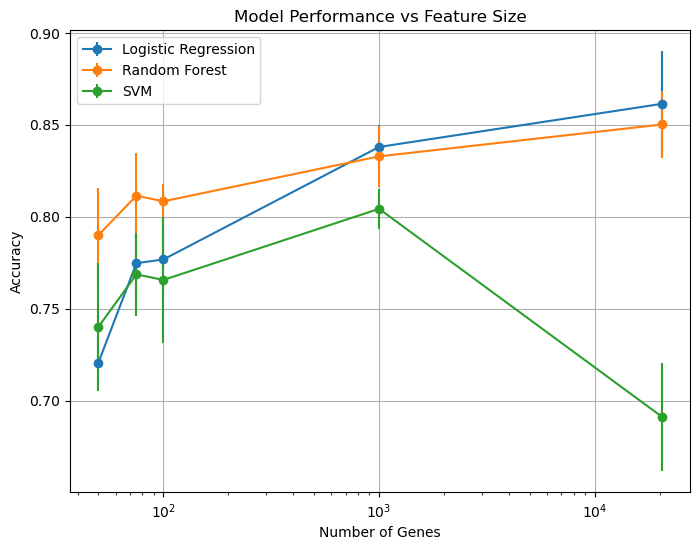

In [392]:
plt.figure(figsize = (8,6))

for model in results_df["model"].unique():
    subset= results_df[results_df["model"] == model]
    subset= subset.sort_values(by= "n_genes")

    plt.errorbar(
        subset["n_genes"],
        subset["accuracy_mean"],
        yerr=subset["accuracy_std"],
        marker='o',
        label=model
    )

plt.xscale("log")

plt.xlabel("Number of Genes")
plt.ylabel("Accuracy")
plt.title("Model Performance vs Feature Size")
plt.legend()
plt.grid(True)
plt.savefig("accuracy_plot.png", dpi= 300, bbox_inches="tight")

plt.show()

In [370]:
# due to the wide rage of feature size, the x-axis was plotted on a logarithmic scale to
#improve interpretability.

#too many genes hurt SVM, too few genes hurt all models, mid-rage(100-1000)best tradeoff
#logistic-best for large feature spaces
#RF most stable overall
#SVM sensitive to dimensionality

In [374]:
subtype_df = pd.read_csv("subtype_results.csv")

In [376]:
subtype_summary = subtype_df.groupby(
    ["n_genes", "model", "subtype"]
)["f1_score"].mean().reset_index()

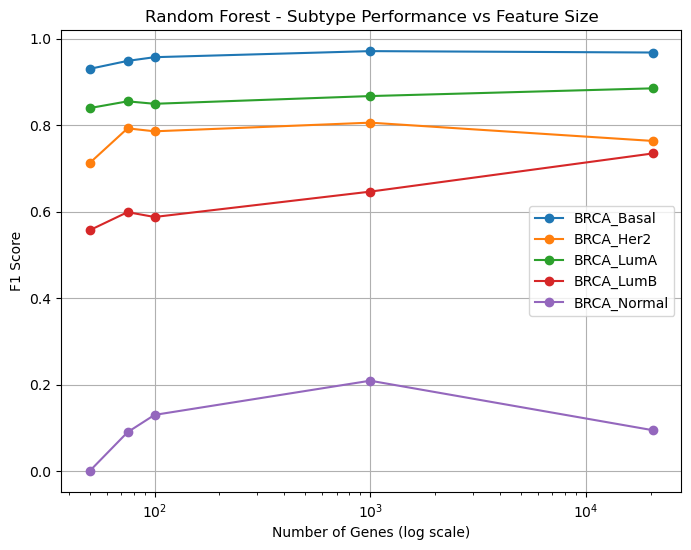

In [378]:
model_name = "Random Forest"  # change to test others

plt.figure(figsize=(8,6))

subset = subtype_summary[subtype_summary["model"] == model_name]

for subtype in subset["subtype"].unique():
    sub_data = subset[subset["subtype"] == subtype]
    sub_data = sub_data.sort_values(by="n_genes")
    
    plt.plot(
        sub_data["n_genes"],
        sub_data["f1_score"],
        marker='o',
        label=subtype
    )

plt.xscale("log")

plt.xlabel("Number of Genes (log scale)")
plt.ylabel("F1 Score")
plt.title(f"{model_name} - Subtype Performance vs Feature Size")
plt.legend()
plt.grid(True)

plt.show()

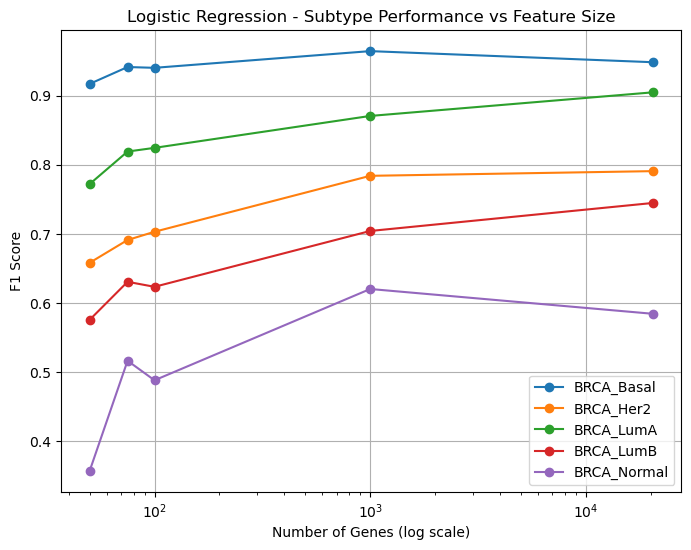

In [380]:
model_name = "Logistic Regression"  # change to test others

plt.figure(figsize=(8,6))

subset = subtype_summary[subtype_summary["model"] == model_name]

for subtype in subset["subtype"].unique():
    sub_data = subset[subset["subtype"] == subtype]
    sub_data = sub_data.sort_values(by="n_genes")
    
    plt.plot(
        sub_data["n_genes"],
        sub_data["f1_score"],
        marker='o',
        label=subtype
    )

plt.xscale("log")

plt.xlabel("Number of Genes (log scale)")
plt.ylabel("F1 Score")
plt.title(f"{model_name} - Subtype Performance vs Feature Size")
plt.legend()
plt.grid(True)

plt.show()

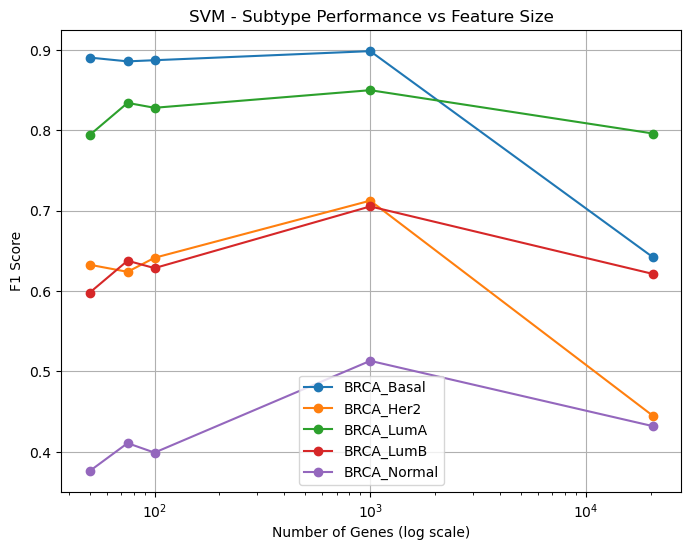

In [382]:
model_name = "SVM"  # change to test others

plt.figure(figsize=(8,6))

subset = subtype_summary[subtype_summary["model"] == model_name]

for subtype in subset["subtype"].unique():
    sub_data = subset[subset["subtype"] == subtype]
    sub_data = sub_data.sort_values(by="n_genes")
    
    plt.plot(
        sub_data["n_genes"],
        sub_data["f1_score"],
        marker='o',
        label=subtype
    )

plt.xscale("log")

plt.xlabel("Number of Genes (log scale)")
plt.ylabel("F1 Score")
plt.title(f"{model_name} - Subtype Performance vs Feature Size")
plt.legend()
plt.grid(True)

plt.show()

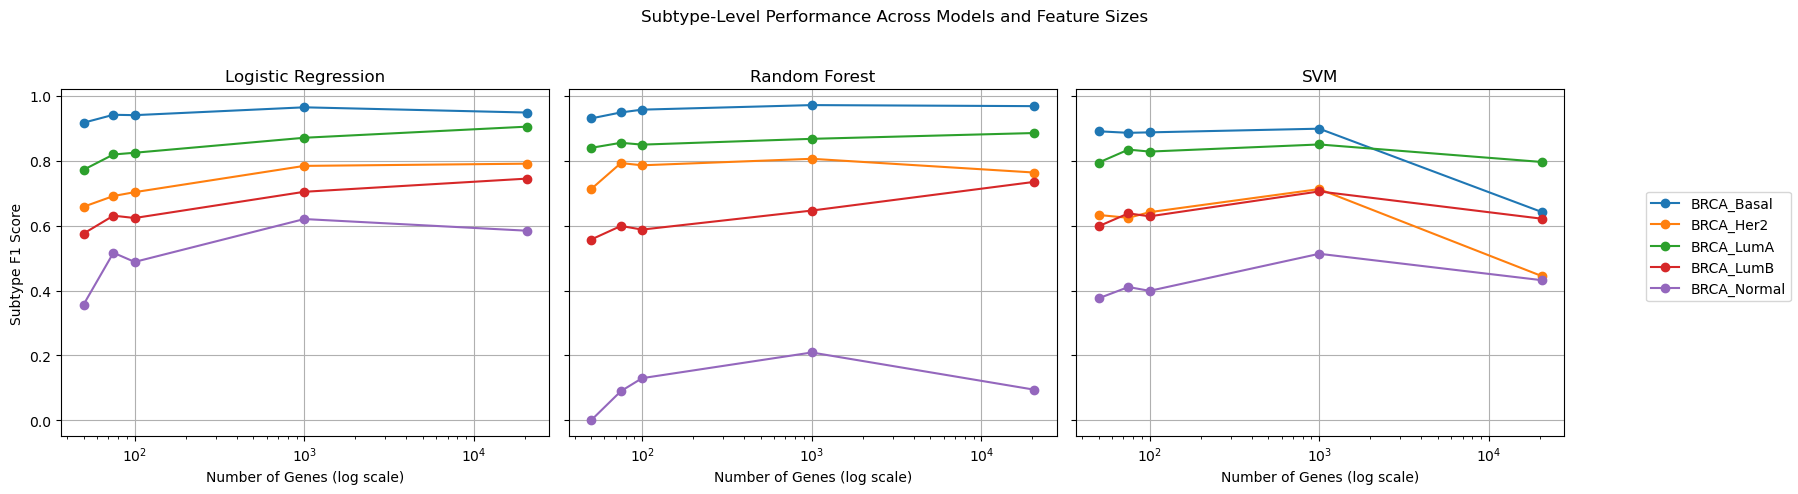

In [394]:
models_to_plot = ["Logistic Regression", "Random Forest", "SVM"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, model_name in zip(axes, models_to_plot):
    subset = subtype_summary[subtype_summary["model"] == model_name]
    
    for subtype in subset["subtype"].unique():
        sub_data = subset[subset["subtype"] == subtype]
        sub_data = sub_data.sort_values(by="n_genes")
        
        ax.plot(
            sub_data["n_genes"],
            sub_data["f1_score"],
            marker="o",
            label=subtype
        )
    
    ax.set_xscale("log")
    ax.set_title(model_name)
    ax.set_xlabel("Number of Genes (log scale)")
    ax.grid(True)

axes[0].set_ylabel("Subtype F1 Score")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")

plt.suptitle("Subtype-Level Performance Across Models and Feature Sizes")
plt.tight_layout(rect=[0, 0, 0.88, 0.95])
plt.savefig("subtype_plot.png", dpi=300, bbox_inches="tight")

plt.show()

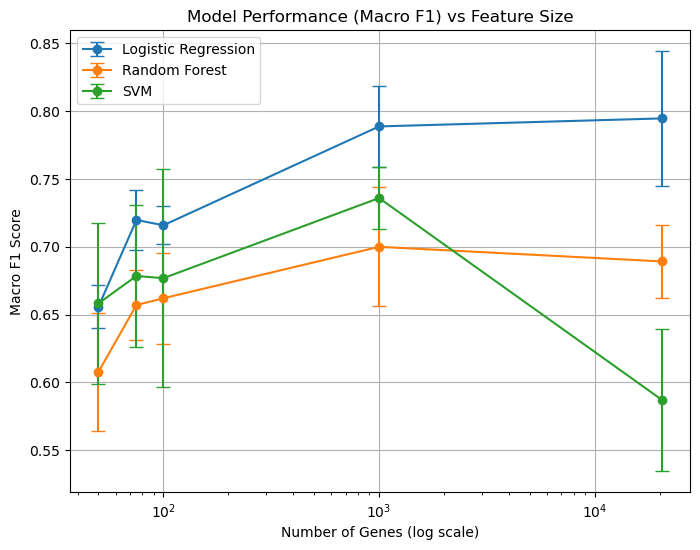

In [396]:
plt.figure(figsize=(8,6))

for model in results_df["model"].unique():
    subset = results_df[results_df["model"] == model]
    subset = subset.sort_values(by="n_genes")
    
    plt.errorbar(
        subset["n_genes"],
        subset["macro_f1_mean"],
        yerr=subset["macro_f1_std"],
        marker='o',
        capsize=5,
        label=model
    )

plt.xscale("log")

plt.xlabel("Number of Genes (log scale)")
plt.ylabel("Macro F1 Score")
plt.title("Model Performance (Macro F1) vs Feature Size")
plt.legend()
plt.grid(True)

plt.savefig("macro_f1_plot.png", dpi=300, bbox_inches="tight")  # ✅ SAVE
plt.show()

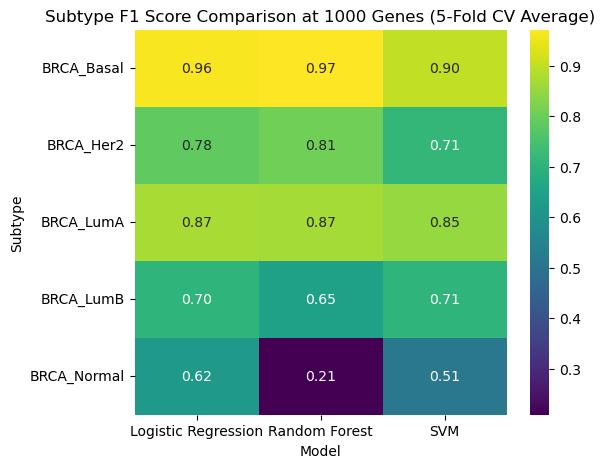

In [418]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use cross-validated average F1 scores at 1000 genes
heatmap_data = subtype_summary[subtype_summary["n_genes"] == 1000].pivot(
    index="subtype",
    columns="model",
    values="f1_mean"
)

plt.figure(figsize=(6,5))
sns.heatmap(heatmap_data, annot=True, cmap="viridis", fmt=".2f")

plt.title("Subtype F1 Score Comparison at 1000 Genes (5-Fold CV Average)")
plt.ylabel("Subtype")
plt.xlabel("Model")

plt.savefig("heatmap_cv_1000genes.png", dpi=300, bbox_inches="tight")
plt.show()

In [412]:
table_df = results_df.copy()

# Shorten model names
table_df["model"] = table_df["model"].replace({
    "Logistic Regression": "LR",
    "Random Forest": "RF",
    "SVM": "SVM"
})

# Format values
table_df["Acc"] = table_df["accuracy_mean"].round(3)
table_df["Macro F1"] = table_df["macro_f1_mean"].round(3)
table_df["Wtd F1"] = table_df["weighted_f1_mean"].round(3)

# Keep needed columns
table_df = table_df[["n_genes", "model", "Acc", "Macro F1", "Wtd F1"]]

# Sort in your desired order
gene_order = [20518, 1000, 100, 75, 50]
model_order = ["LR", "RF", "SVM"]

table_df["n_genes"] = pd.Categorical(table_df["n_genes"], categories=gene_order, ordered=True)
table_df["model"] = pd.Categorical(table_df["model"], categories=model_order, ordered=True)

table_df = table_df.sort_values(["n_genes", "model"])

table_df

,n_genes,model,Acc,Macro F1,Wtd F1
0,20518,LR,0.861,0.795,0.860
1,20518,RF,0.850,0.689,0.831
2,20518,SVM,0.691,0.587,0.693
3,1000,LR,0.838,0.789,0.838
4,1000,RF,0.833,0.700,0.812
5,1000,SVM,0.804,0.736,0.806
6,100,LR,0.777,0.716,0.782
7,100,RF,0.808,0.662,0.784
8,100,SVM,0.766,0.677,0.768
9,75,LR,0.775,0.720,0.781


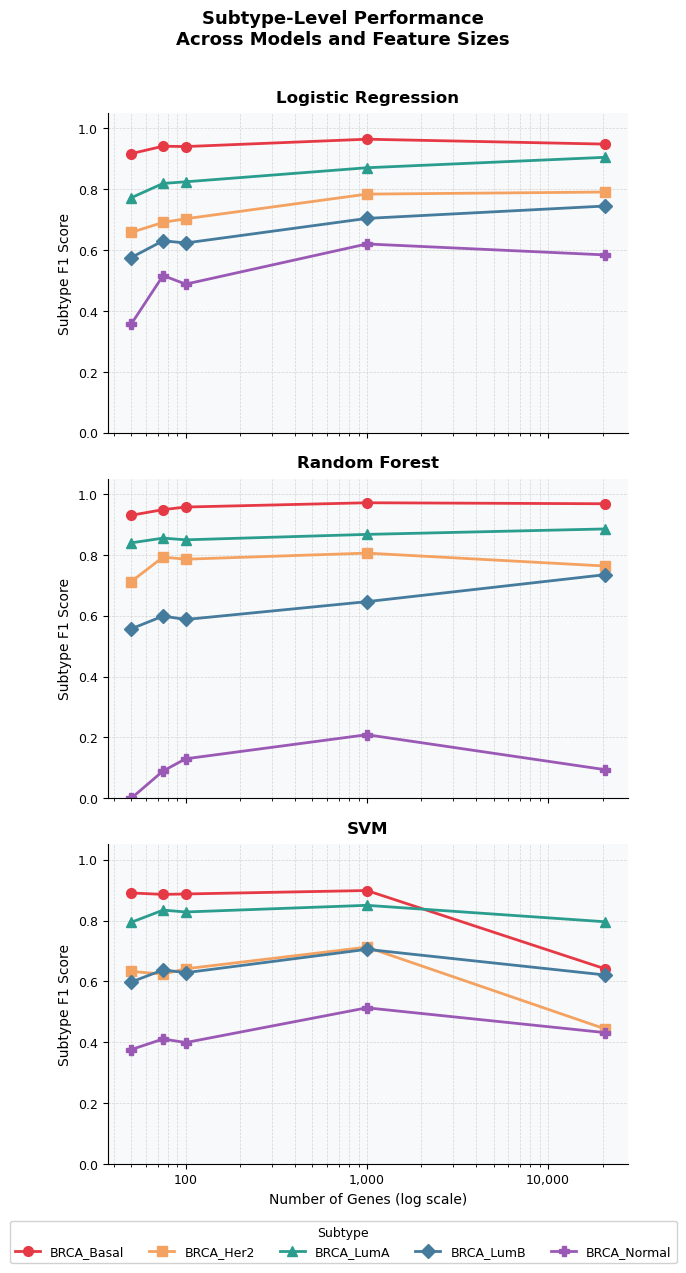

In [422]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

models_to_plot = ["Logistic Regression", "Random Forest", "SVM"]

subtype_colors = {
    "BRCA_Basal":  "#E63946",
    "BRCA_Her2":   "#F4A261",
    "BRCA_LumA":   "#2A9D8F",
    "BRCA_LumB":   "#457B9D",
    "BRCA_Normal": "#9B59B6"
}

subtype_markers = {
    "BRCA_Basal":  "o",
    "BRCA_Her2":   "s",
    "BRCA_LumA":   "^",
    "BRCA_LumB":   "D",
    "BRCA_Normal": "P"
}

fig, axes = plt.subplots(3, 1, figsize=(6, 12), sharex=True, sharey=True)
fig.patch.set_facecolor("white")

for ax, model_name in zip(axes, models_to_plot):
    subset = subtype_summary[subtype_summary["model"] == model_name]
    ax.set_facecolor("#F8F9FA")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, color="#CCCCCC", alpha=0.8)
    ax.set_axisbelow(True)

    for subtype in ["BRCA_Basal", "BRCA_Her2", "BRCA_LumA", "BRCA_LumB", "BRCA_Normal"]:
        sub_data = subset[subset["subtype"] == subtype].sort_values(by="n_genes")
        if sub_data.empty:
            continue
        ax.plot(
            sub_data["n_genes"],
            sub_data["f1_mean"],
            marker=subtype_markers[subtype],
            color=subtype_colors[subtype],
            linewidth=2,
            markersize=7,
            label=subtype
        )

    ax.set_xscale("log")
    ax.set_title(model_name, fontsize=12, fontweight="bold", pad=8)
    ax.set_ylabel("Subtype F1 Score", fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.tick_params(axis="both", labelsize=9)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[-1].set_xlabel("Number of Genes (log scale)", fontsize=10)
axes[-1].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x):,}"
))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=5,
    fontsize=9,
    frameon=True,
    framealpha=0.9,
    edgecolor="#CCCCCC",
    title="Subtype",
    title_fontsize=9
)

fig.suptitle(
    "Subtype-Level Performance\nAcross Models and Feature Sizes",
    fontsize=13,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.savefig("subtype_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [424]:
from collections import Counter

gene_counts = Counter()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_genes = 1000

for train_idx, val_idx in skf.split(x, y):
    x_train = x.iloc[train_idx]
    gene_variance = x_train.var()
    top_genes = gene_variance.sort_values(ascending=False).head(n_genes).index.tolist()
    gene_counts.update(top_genes)

# Genes appearing in all 5 folds
stable_genes = [gene for gene, count in gene_counts.items() if count == 5]
print(f"Genes selected in all 5 folds: {len(stable_genes)}")
print(stable_genes[:50])

# Save full list
import pandas as pd
gene_df = pd.DataFrame(gene_counts.items(), columns=["gene", "fold_count"])
gene_df = gene_df.sort_values("fold_count", ascending=False)
gene_df.to_csv("selected_genes.csv", index=False)

Genes selected in all 5 folds: 885
['CPB1', 'COL1A1', 'COL1A2', 'FN1', 'COL3A1', 'BMS1P20', 'ADAM6', 'SCGB2A2', 'LTF', 'SPARC', 'MGP', 'PIP', 'CD24', 'IGFBP5', 'RPL19', 'GAPDH', 'C4A', 'ACTB', 'ERBB2', 'SLC39A6', 'CHGB', 'MUCL1', 'EEF1A1', 'APOD', 'CD74', 'C4orf7', 'AZGP1', 'SERPINA3', 'CTSD', 'KRT19', 'CARTPT', 'B2M', 'IGF2', 'HLA-B', 'DCD', 'FASN', 'XBP1', 'ACTG1', 'FTL', 'PABPC1', 'KRT8', 'RPL8', 'CXCL14', 'POSTN', 'TPT1', 'EEF2', 'ALDOA', 'CLU', 'KRT14', 'COL6A3']


In [426]:
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, class_weight="balanced")
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500, random_state=42, class_weight="balanced"
    ),
    "SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", class_weight="balanced", random_state=42)
    )
}

# Collect per-fold macro F1 at 1000 genes (your best feature size)
n_genes = 1000
top_genes = x.var().sort_values(ascending=False).head(n_genes).index
x_reduced = x[top_genes]

fold_scores = {name: [] for name in models}

for train_idx, val_idx in skf.split(x_reduced, y):
    x_train = x_reduced.iloc[train_idx]
    x_val = x_reduced.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]
    
    # Feature selection within fold
    gene_var = x_train.var()
    top = gene_var.sort_values(ascending=False).head(n_genes).index
    x_train_fs = x_train[top]
    x_val_fs = x_val[top]
    
    for name, model in models.items():
        m = clone(model)
        m.fit(x_train_fs, y_train)
        y_pred = m.predict(x_val_fs)
        score = f1_score(y_val, y_pred, average="macro", zero_division=0)
        fold_scores[name].append(score)

# Print per-fold scores
for name, scores in fold_scores.items():
    print(f"{name}: {[round(s,4) for s in scores]}")
    print(f"  Mean: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

print("\n--- Statistical Tests (Wilcoxon Signed-Rank) ---")

lr = fold_scores["Logistic Regression"]
rf = fold_scores["Random Forest"]
svm = fold_scores["SVM"]

stat, p = stats.wilcoxon(lr, rf)
print(f"LR vs RF:  statistic={stat:.3f}, p={p:.4f}")

stat, p = stats.wilcoxon(lr, svm)
print(f"LR vs SVM: statistic={stat:.3f}, p={p:.4f}")

stat, p = stats.wilcoxon(rf, svm)
print(f"RF vs SVM: statistic={stat:.3f}, p={p:.4f}")

Logistic Regression: [0.7837, 0.8218, 0.7837, 0.7402, 0.8142]
  Mean: 0.7887 ± 0.0288
Random Forest: [0.7806, 0.6861, 0.6685, 0.6557, 0.7729]
  Mean: 0.7127 ± 0.0532
SVM: [0.6914, 0.7359, 0.7275, 0.7085, 0.7189]
  Mean: 0.7164 ± 0.0155

--- Statistical Tests (Wilcoxon Signed-Rank) ---
LR vs RF:  statistic=0.000, p=0.0625
LR vs SVM: statistic=0.000, p=0.0625
RF vs SVM: statistic=7.000, p=1.0000
